In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

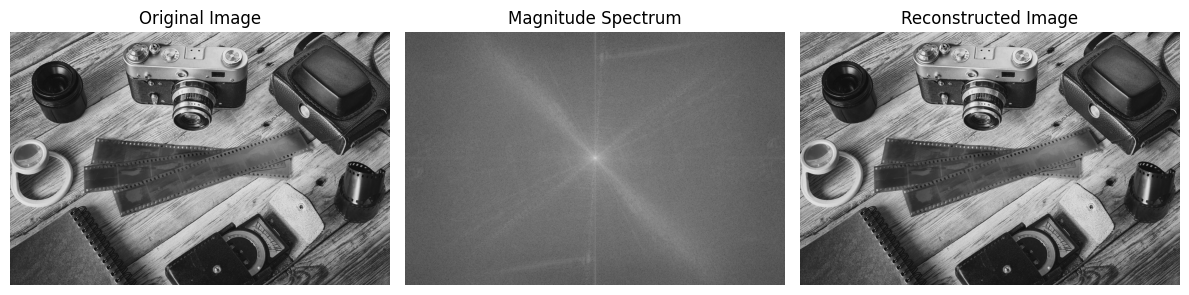

In [3]:
# Load the image in grayscale
image = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

# Check if image loaded correctly
if image is None:
    print("Error: Image not found. Please ensure 'lena.jpg' is in the current directory.")
    exit()

# Compute Discrete Fourier Transform (DFT)
dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)

# Shift zero frequency component to center
dft_shift = np.fft.fftshift(dft)

# Compute magnitude spectrum
magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
magnitude_spectrum = 20 * np.log(magnitude + 1)

# Inverse shift
dft_ishift = np.fft.ifftshift(dft_shift)

# Inverse DFT
idft = cv2.idft(dft_ishift)

# Reconstruct image from real and imaginary parts
reconstructed_image = cv2.magnitude(idft[:, :, 0], idft[:, :, 1])

# Normalize reconstructed image
reconstructed_image = cv2.normalize(reconstructed_image, None, 0, 255, cv2.NORM_MINMAX)
reconstructed_image = reconstructed_image.astype(np.uint8)

# Resize reconstructed image
reconstructed_image = cv2.resize(reconstructed_image, (image.shape[1], image.shape[0]))

# Display results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Magnitude Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Reconstructed Image")
plt.imshow(reconstructed_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

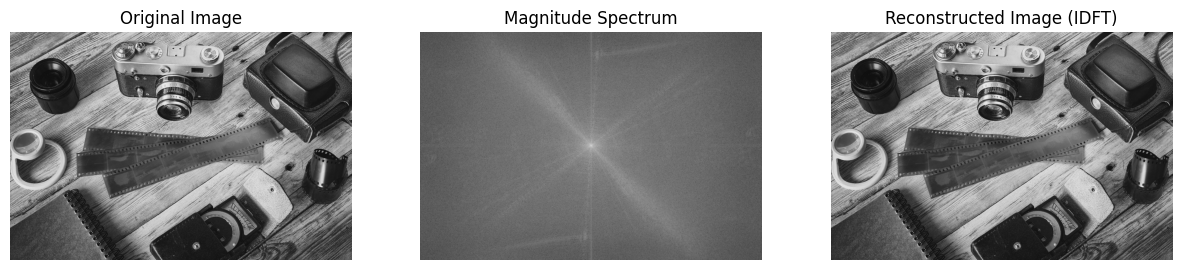

True

In [4]:
# Display the images using subplots with controlled aspect ratio
plt.figure(figsize=(15, 5))  # Adjusted figure size for 3 subplots

# Original Image
plt.subplot(1, 3, 1)  # 1 row, 3 columns, first subplot
plt.imshow(image, cmap='gray', aspect='equal')
plt.title('Original Image')
plt.axis('off')

# Magnitude Spectrum
plt.subplot(1, 3, 2)  # second subplot
plt.imshow(magnitude_spectrum, cmap='gray', aspect='equal')
plt.title('Magnitude Spectrum')
plt.axis('off')

# Reconstructed Image
plt.subplot(1, 3, 3)  # third subplot
plt.imshow(reconstructed_image, cmap='gray', aspect='equal')
plt.title('Reconstructed Image (IDFT)')
plt.axis('off')

# Show all images
plt.show()

# Save the results
cv2.imwrite('magnitude_spectrum.jpg', magnitude_spectrum)
cv2.imwrite('reconstructed_image.jpg', reconstructed_image)